In [ ]:
!pip install pytorch-gan-metrics

In [ ]:
!pip install pytorch-gan-metrics

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Subset, TensorDataset, ConcatDataset, Dataset, random_split
from torchvision import datasets, transforms, models
import matplotlib.pyplot as plt
import numpy as np
from scipy import linalg
from scipy.stats import entropy
import os
import zipfile
import gdown
import pandas as pd
from google.colab import drive
from PIL import Image

In [ ]:
# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [ ]:
# Load pre-trained Inception V3
inception_v3 = models.inception_v3(pretrained=True, transform_input=False).eval().to(device)
inception_v3.fc = nn.Identity()  # Remove classification layer for FID features

def get_inception_features(images, model, batch_size=50):
    model.eval()
    transform = transforms.Compose([
        transforms.Resize((299, 299)),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    features = []
    with torch.no_grad():
        for i in range(0, len(images), batch_size):
            batch = images[i:i+batch_size].to(device)
            batch = torch.stack([transform(img) for img in batch])
            feat = model(batch)
            features.append(feat.cpu())
    return torch.cat(features, dim=0)

def compute_inception_score(images, model, splits=10):
    images = (images + 1) / 2  # Denormalize to [0, 1]
    preds = []
    with torch.no_grad():
        for i in range(0, len(images), 50):
            batch = images[i:i+50].to(device)
            batch = torch.stack([transforms.Resize((299, 299))(img) for img in batch])
            batch = transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])(batch)
            pred = F.softmax(model(batch), dim=1)
            preds.append(pred.cpu())
    preds = torch.cat(preds, dim=0).numpy()

    scores = []
    n = preds.shape[0]
    for k in range(splits):
        part = preds[k * (n // splits): (k + 1) * (n // splits)]
        py = np.mean(part, axis=0)
        score = np.exp(np.mean([entropy(p, py) for p in part]))
        scores.append(score)
    return np.mean(scores), np.std(scores)

def compute_fid(real_images, fake_images, model):
    real_images = (real_images + 1) / 2  # Denormalize
    fake_images = (fake_images + 1) / 2
    real_feats = get_inception_features(real_images, model)
    fake_feats = get_inception_features(fake_images, model)
    mu1, sigma1 = real_feats.mean(dim=0).numpy(), np.cov(real_feats.numpy(), rowvar=False)
    mu2, sigma2 = fake_feats.mean(dim=0).numpy(), np.cov(fake_feats.numpy(), rowvar=False)
    diff = mu1 - mu2
    covmean = linalg.sqrtm(sigma1.dot(sigma2), disp=False)[0]
    if np.iscomplexobj(covmean):
        covmean = covmean.real
    fid = diff.dot(diff) + np.trace(sigma1 + sigma2 - 2 * covmean)
    return fid

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=Inception_V3_Weights.IMAGENET1K_V1`. You can also use `weights=Inception_V3_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/inception_v3_google-0cc3c7bd.pth" to /root/.cache/torch/hub/checkpoints/inception_v3_google-0cc3c7bd.pth
100%|██████████| 104M/104M [00:01<00:00, 60.1MB/s]


In [ ]:
drive.mount('/content/drive')

gdrive_path = "/content/drive/MyDrive/img_align_celeba.zip"  # Update with the correct path if needed
data_root = "./data/celeba"
os.makedirs(data_root, exist_ok=True)


local_zip = os.path.join(data_root, "celeba_dataset.zip")
os.system(f"cp '{gdrive_path}' '{local_zip}'")

print("Extracting CelebA dataset...")
with zipfile.ZipFile(local_zip, "r") as zip_ref:
    zip_ref.extractall(data_root)

print("Extraction complete!")


Mounted at /content/drive
Extracting CelebA dataset...
Extraction complete!


In [ ]:

attr_path = "/content/list_attr_celeba.txt"

# Read attributes file, skipping the first row (which contains the number of images)
attr_df = pd.read_csv(attr_path, sep='\s+', skiprows=1)

# Reset index to make filenames a column instead of an index
attr_df.reset_index(inplace=True)
attr_df.rename(columns={"index": "filename"}, inplace=True)

# Print first few rows to confirm the fix
print(attr_df.head())


     filename  5_o_Clock_Shadow  Arched_Eyebrows  Attractive  Bags_Under_Eyes  \
0  000001.jpg                -1                1           1               -1   
1  000002.jpg                -1               -1          -1                1   
2  000003.jpg                -1               -1          -1               -1   
3  000004.jpg                -1               -1           1               -1   
4  000005.jpg                -1                1           1               -1   

   Bald  Bangs  Big_Lips  Big_Nose  Black_Hair  ...  Sideburns  Smiling  \
0    -1     -1        -1        -1          -1  ...         -1        1   
1    -1     -1        -1         1          -1  ...         -1        1   
2    -1     -1         1        -1          -1  ...         -1       -1   
3    -1     -1        -1        -1          -1  ...         -1       -1   
4    -1     -1         1        -1          -1  ...         -1       -1   

   Straight_Hair  Wavy_Hair  Wearing_Earrings  Wearing_Hat  We

In [ ]:
# Define paths
data_root = "/content/data/celeba"
img_folder = os.path.join(data_root, "img_align_celeba")
attr_path = "list_attr_celeba.txt" # Attribute file

# Load attributes file
attr_df = pd.read_csv(attr_path, sep='\s+', skiprows=1)
attr_df.reset_index(inplace=True)
attr_df.rename(columns={"index": "filename"}, inplace=True)

# Define custom dataset
class CelebADataset(Dataset):
    def __init__(self, dataset_df, img_folder, transform=None):
        self.dataset_df = dataset_df
        self.img_folder = img_folder
        self.transform = transform
        self.image_names = self.dataset_df["filename"].values
        self.labels = self.dataset_df.iloc[:, 1:].values  # Exclude filename column
        self.attr_names = self.dataset_df.columns[1:].tolist()  # Store attribute names

    def __len__(self):
        return len(self.image_names)

    def __getitem__(self, idx):
        img_name = self.image_names[idx]
        img_path = os.path.join(self.img_folder, img_name)
        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        label = torch.tensor(self.labels[idx], dtype=torch.float32)
        return image, label

# Define transformations
transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))  # Normalize to [-1, 1]
])

# Create full dataset
full_dataset = CelebADataset(attr_df, img_folder, transform=transform)

# Get attribute names
attr_names = full_dataset.attr_names  # Extract attribute names before splitting

# Manually split dataset: 80% train, 10% valid, 10% test
total_size = len(full_dataset)
train_size = int(0.8 * total_size)
valid_size = int(0.1 * total_size)
test_size = total_size - train_size - valid_size  # Ensure all data is used

train_dataset, valid_dataset, test_dataset = random_split(full_dataset, [train_size, valid_size, test_size])

# Print dataset info
print(f"Train set size: {len(train_dataset)}")
print(f"Validation set size: {len(valid_dataset)}")
print(f"Test set size: {len(test_dataset)}")
print("Dataset successfully prepared!")


Train set size: 162079
Validation set size: 20259
Test set size: 20261
Dataset successfully prepared!


In [ ]:
# Find the index for 'Young' attribute
young_index = attr_names.index("Young")

# Custom dataset to return image and 'Young' label
class CelebAYoungDataset(Dataset):
    def __init__(self, celeba_subset, young_index):
        self.celeba_subset = celeba_subset
        self.young_index = young_index

    def __len__(self):
        return len(self.celeba_subset)

    def __getitem__(self, idx):
        image, attributes = self.celeba_subset[idx]  # Unpack data
        young_label = attributes[self.young_index].float()  # Extract 'Young' label
        return image, young_label

In [ ]:
# Create datasets with 'Young' label
train_dataset_young = CelebAYoungDataset(train_dataset, young_index)
valid_dataset_young = CelebAYoungDataset(valid_dataset, young_index)
test_dataset_young = CelebAYoungDataset(test_dataset, young_index)


In [ ]:
# Data loaders
batch_size = 64
train_loader = DataLoader(train_dataset_young, batch_size=batch_size, shuffle=True)
valid_loader = DataLoader(valid_dataset_young, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset_young, batch_size=batch_size, shuffle=False)

print("DataLoaders successfully created")

DataLoaders successfully created


In [ ]:
# Visualization function
def plot_images(dataset, num_images=16, title="Sample Images"):
    fig, axes = plt.subplots(4, 4, figsize=(10, 10))
    plt.suptitle(title)
    for i, ax in enumerate(axes.flat):
        if i < num_images:
            image, label = dataset[i]
            image = image.permute(1, 2, 0)  # CxHxW to HxWxC
            image = (image + 1) / 2  # Denormalize to [0, 1]
            ax.imshow(image)
            ax.set_title('Young' if label == 1 else 'Old')
            ax.axis('off')
    plt.show()

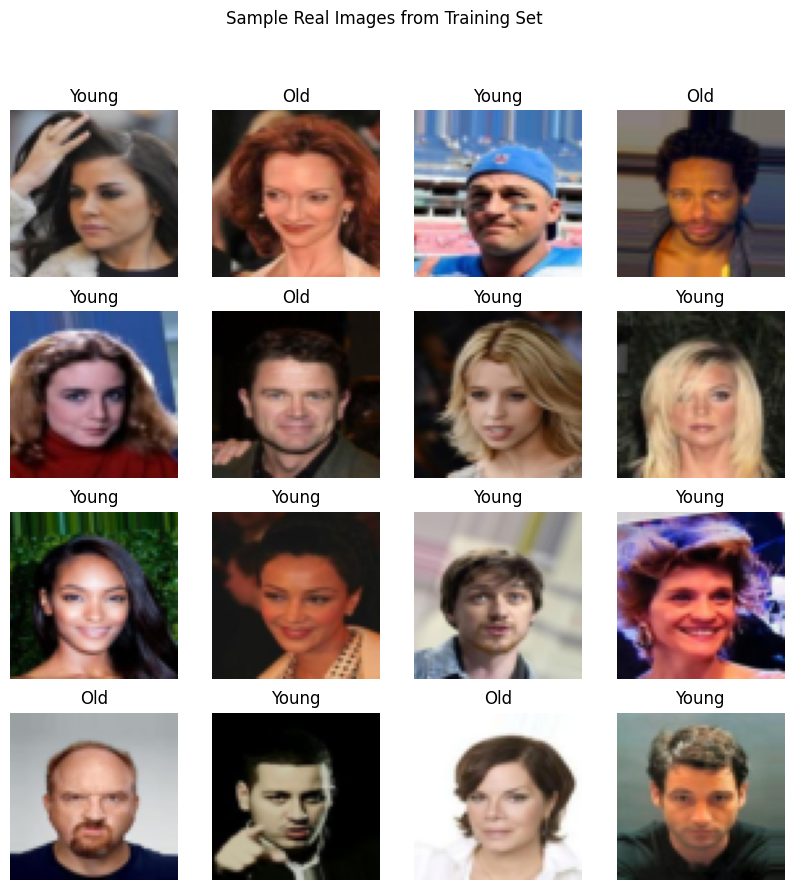

In [ ]:
# Visualize sample images
plot_images(train_dataset_young, title="Sample Real Images from Training Set")

In [ ]:
# ### Part 2: WGAN Implementation for Synthetic Data Generation ###
print("\nPart 2: WGAN Implementation")

# Generator model
class Generator(nn.Module):
    def __init__(self, latent_dim=100):
        super(Generator, self).__init__()
        self.main = nn.Sequential(
            nn.ConvTranspose2d(latent_dim, 512, 4, 1, 0, bias=False),
            nn.BatchNorm2d(512),
            nn.ReLU(True),
            nn.ConvTranspose2d(512, 256, 4, 2, 1, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(True),
            nn.ConvTranspose2d(256, 128, 4, 2, 1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(True),
            nn.ConvTranspose2d(128, 64, 4, 2, 1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(True),
            nn.ConvTranspose2d(64, 3, 4, 2, 1, bias=False),
            nn.Tanh()  # Output range [-1, 1]
        )

    def forward(self, x):
        x = x.view(-1, latent_dim, 1, 1)
        return self.main(x)


Part 2: WGAN Implementation


In [ ]:
# Critic model
class Critic(nn.Module):
    def __init__(self):
        super(Critic, self).__init__()
        self.main = nn.Sequential(
            nn.Conv2d(3, 64, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(64, 128, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(128, 256, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(256, 512, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
        )
        self.fc = nn.Linear(512 * 4 * 4, 1)

    def forward(self, x):
        x = self.main(x)
        x = x.view(-1, 512 * 4 * 4)
        return self.fc(x)

In [ ]:
# Initialize models and optimizers
latent_dim = 100
n_critic = 1
clip_value = 0.01
lr = 5e-5
num_epochs = 5

In [ ]:
generator = Generator(latent_dim).to(device)
critic = Critic().to(device)
optimizer_G = optim.RMSprop(generator.parameters(), lr=lr)
optimizer_C = optim.RMSprop(critic.parameters(), lr=lr)

In [ ]:
# Training WGAN
critic_losses = []
generator_losses = []

In [ ]:
for epoch in range(num_epochs):
    for i, (real_images, _) in enumerate(train_loader):
        real_images = real_images.to(device)
        current_batch_size = real_images.size(0)

        # Train critic
        for _ in range(n_critic):
            z = torch.randn(current_batch_size, latent_dim, device=device)
            fake_images = generator(z)
            real_outputs = critic(real_images)
            fake_outputs = critic(fake_images.detach())
            critic_loss = -(torch.mean(real_outputs) - torch.mean(fake_outputs))
            optimizer_C.zero_grad()
            critic_loss.backward()
            optimizer_C.step()
            for p in critic.parameters():
                p.data.clamp_(-clip_value, clip_value)

        # Train generator
        z = torch.randn(current_batch_size, latent_dim, device=device)
        fake_images = generator(z)
        fake_outputs = critic(fake_images)
        generator_loss = -torch.mean(fake_outputs)
        optimizer_G.zero_grad()
        generator_loss.backward()
        optimizer_G.step()

        critic_losses.append(critic_loss.item())
        generator_losses.append(generator_loss.item())

        if i % 100 == 0:
            print(f'Epoch [{epoch}/{num_epochs}], Step [{i}/{len(train_loader)}], '
                  f'Critic Loss: {critic_loss.item():.4f}, Generator Loss: {generator_loss.item():.4f}')

Epoch [0/5], Step [0/2533], Critic Loss: -0.0036, Generator Loss: 0.0020
Epoch [0/5], Step [100/2533], Critic Loss: -4.1226, Generator Loss: -10.4262
Epoch [0/5], Step [200/2533], Critic Loss: -8.9395, Generator Loss: 18.8473
Epoch [0/5], Step [300/2533], Critic Loss: -4.0454, Generator Loss: -4.6617
Epoch [0/5], Step [400/2533], Critic Loss: -8.2967, Generator Loss: 14.2280
Epoch [0/5], Step [500/2533], Critic Loss: -11.3237, Generator Loss: -3.6626
Epoch [0/5], Step [600/2533], Critic Loss: 9.2482, Generator Loss: -12.2805
Epoch [0/5], Step [700/2533], Critic Loss: -17.6423, Generator Loss: 62.5468
Epoch [0/5], Step [800/2533], Critic Loss: 2.2587, Generator Loss: -30.1319
Epoch [0/5], Step [900/2533], Critic Loss: -10.4789, Generator Loss: 37.3910
Epoch [0/5], Step [1000/2533], Critic Loss: -14.3658, Generator Loss: -69.4256
Epoch [0/5], Step [1100/2533], Critic Loss: 8.3029, Generator Loss: 51.4362
Epoch [0/5], Step [1200/2533], Critic Loss: -6.0137, Generator Loss: -0.4452
Epoch [

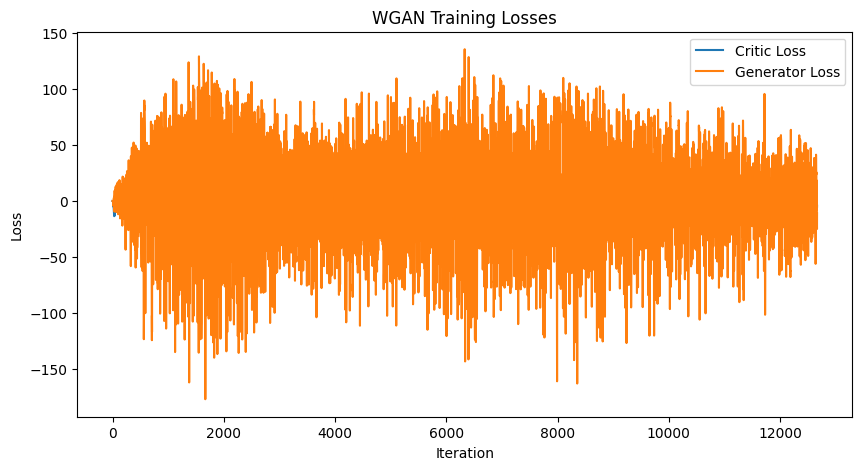

In [ ]:
# Plot losses
plt.figure(figsize=(10, 5))
plt.plot(critic_losses, label='Critic Loss')
plt.plot(generator_losses, label='Generator Loss')
plt.xlabel('Iteration')

plt.ylabel('Loss')
plt.title('WGAN Training Losses')
plt.legend()
plt.show()

In [ ]:
# Evaluate generated images
generator.eval()
with torch.no_grad():
    z = torch.randn(10000, latent_dim, device=device)
    synthetic_images = generator(z).cpu()
    synthetic_images_eval = (synthetic_images + 1) / 2  # Denormalize to [0, 1] for metrics

In [ ]:
synthetic_images_eval

tensor([[[[0.6107, 0.6887, 0.7082,  ..., 0.7541, 0.7282, 0.5910],
          [0.7038, 0.6929, 0.6311,  ..., 0.7590, 0.7770, 0.7424],
          [0.6961, 0.6613, 0.5548,  ..., 0.7189, 0.7140, 0.7408],
          ...,
          [0.1395, 0.0497, 0.0376,  ..., 0.4181, 0.3628, 0.4697],
          [0.1949, 0.0503, 0.0517,  ..., 0.3237, 0.3576, 0.5089],
          [0.2170, 0.0791, 0.0644,  ..., 0.4384, 0.4559, 0.4677]],

         [[0.6071, 0.7236, 0.6589,  ..., 0.7212, 0.6922, 0.6227],
          [0.6894, 0.6580, 0.5995,  ..., 0.7274, 0.7154, 0.6697],
          [0.6790, 0.6606, 0.5806,  ..., 0.6805, 0.6508, 0.7199],
          ...,
          [0.1332, 0.0412, 0.0298,  ..., 0.4313, 0.3865, 0.4259],
          [0.0728, 0.0500, 0.0448,  ..., 0.3155, 0.3194, 0.4428],
          [0.2082, 0.0904, 0.0745,  ..., 0.3550, 0.3830, 0.4169]],

         [[0.6014, 0.6884, 0.6653,  ..., 0.6929, 0.7101, 0.6006],
          [0.6733, 0.6469, 0.6203,  ..., 0.7102, 0.7030, 0.6646],
          [0.6771, 0.6585, 0.6010,  ..., 0

In [ ]:
# Sample real images for evaluation
real_indices = np.random.choice(len(train_dataset), 10000, replace=False)
real_subset = Subset(train_dataset, real_indices)
real_loader = DataLoader(real_subset, batch_size=100, shuffle=False)
real_images = []
for images, _ in real_loader:
    real_images.append(images)
real_images = torch.cat(real_images, dim=0)
real_images_eval = (real_images + 1) / 2  # Denormalize to [0, 1]

In [ ]:
# Compute IS and FID using custom functions
is_score, is_std = compute_inception_score(synthetic_images_eval, inception_v3)
fid_score = compute_fid(real_images_eval, synthetic_images_eval, inception_v3)
print(f'Inception Score: {is_score:.4f} ± {is_std:.4f}')
print(f'FID Score: {fid_score:.4f}')

Inception Score: 1.0558 ± 0.0006
FID Score: 236.7472


In [ ]:
# ### Part 3: Hyperparameter Tuning and Optimization ###
print("\nPart 3: Hyperparameter Tuning")

def train_wgan(latent_dim=100, lr=5e-5, batch_size=64, num_epochs=5):
    generator = Generator(latent_dim).to(device)
    critic = Critic().to(device)
    optimizer_G = optim.RMSprop(generator.parameters(), lr=lr)
    optimizer_C = optim.RMSprop(critic.parameters(), lr=lr)
    train_loader_tune = DataLoader(train_dataset_young, batch_size=batch_size, shuffle=True)

    for epoch in range(num_epochs):
        for real_images, _ in train_loader_tune:
            real_images = real_images.to(device)
            current_batch_size = real_images.size(0)
            for _ in range(n_critic):
                z = torch.randn(current_batch_size, latent_dim, device=device)
                fake_images = generator(z)
                real_outputs = critic(real_images)
                fake_outputs = critic(fake_images.detach())
                critic_loss = -(torch.mean(real_outputs) - torch.mean(fake_outputs))
                optimizer_C.zero_grad()
                critic_loss.backward()
                optimizer_C.step()
                for p in critic.parameters():
                    p.data.clamp_(-clip_value, clip_value)
            z = torch.randn(current_batch_size, latent_dim, device=device)
            fake_images = generator(z)
            fake_outputs = critic(fake_images)
            generator_loss = -torch.mean(fake_outputs)
            optimizer_G.zero_grad()
            generator_loss.backward()
            optimizer_G.step()

    # Evaluate
    generator.eval()
    with torch.no_grad():
        z = torch.randn(5000, latent_dim, device=device)
        synthetic_images = generator(z).cpu()
        synthetic_images = (synthetic_images + 1) / 2
    is_score, _ = compute_inception_score(synthetic_images, inception_v3)
    fid_score = compute_fid(real_images_eval[:5000], synthetic_images, inception_v3)
    return generator, is_score, fid_score


Part 3: Hyperparameter Tuning


In [ ]:
# Experiment with hyperparameters
hyperparams = [
    {'latent_dim': 100, 'lr': 5e-5, 'batch_size': 64},
    {'latent_dim': 100, 'lr': 1e-4, 'batch_size': 64},
    {'latent_dim': 200, 'lr': 5e-5, 'batch_size': 128}
]

In [ ]:
results = []
for params in hyperparams:
    print(f"Training with {params}")
    gen, is_score, fid_score = train_wgan(**params)
    results.append((params, is_score, fid_score))
    print(f"IS: {is_score:.4f}, FID: {fid_score:.4f}")

Training with {'latent_dim': 100, 'lr': 5e-05, 'batch_size': 64}
IS: 1.0498, FID: 202.1106
Training with {'latent_dim': 100, 'lr': 0.0001, 'batch_size': 64}
IS: 1.0590, FID: 166.5436
Training with {'latent_dim': 200, 'lr': 5e-05, 'batch_size': 128}


RuntimeError: Given transposed=1, weight of size [200, 512, 4, 4], expected input[256, 100, 1, 1] to have 200 channels, but got 100 channels instead

In [ ]:
# Select best generator (lowest FID)
best_result = min(results, key=lambda x: x[2])
best_generator = train_wgan(**best_result[0])[0]  # Retrain to get the best generator
print(f"Best hyperparameters: {best_result[0]}, IS: {best_result[1]:.4f}, FID: {best_result[2]:.4f}")

In [ ]:
train_loader = DataLoader(train_dataset_young, batch_size=batch_size, shuffle=True, drop_last=True)


In [ ]:
# ### Part 4: Train a Classifier on Real Data ###
print("\nPart 4: Train Classifier on Real Data")

class CNNClassifier1(nn.Module):
    def __init__(self):
        super(CNNClassifier1, self).__init__()
        self.conv1 = nn.Conv2d(3, 32, 3, 1, 1)
        self.conv2 = nn.Conv2d(32, 64, 3, 1, 1)
        self.conv3 = nn.Conv2d(64, 128, 3, 1, 1)
        self.pool = nn.MaxPool2d(2, 2)
        self.relu = nn.ReLU()

        self.fc1 = nn.Linear(128 * 8 * 8, 512)
        self.fc2 = nn.Linear(512, 1)  # No sigmoid here!

    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))
        x = self.pool(self.relu(self.conv2(x)))
        x = self.pool(self.relu(self.conv3(x)))
        x = x.view(x.size(0), -1)  # Flatten properly
        x = self.relu(self.fc1(x))
        x = self.fc2(x)  # No sigmoid
        return x  # Outputs raw logits



Part 4: Train Classifier on Real Data


In [ ]:
for images, labels in train_loader:
    print(images.shape, labels.shape, labels.dtype)
    break


torch.Size([64, 3, 64, 64]) torch.Size([64]) torch.float32


In [ ]:
# Define loss and optimizer
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = CNNClassifier1().to(device)
criterion = nn.BCEWithLogitsLoss()  # Handles sigmoid internally
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [ ]:


def train_classifier(model, train_loader, valid_loader, optimizer, num_epochs=5):
    for epoch in range(num_epochs):
        model.train()
        train_loss = 0
        for images, labels in train_loader:
            images = images.to(device).float()
            labels = labels.view(-1, 1).to(device).float()  # Reshape to (batch_size, 1)

            optimizer.zero_grad()
            outputs = model(images)  # Output shape should match labels: (batch_size, 1)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * images.size(0)
        train_loss /= len(train_loader.dataset)

        model.eval()
        valid_loss = 0
        correct = 0
        with torch.no_grad():
            for images, labels in valid_loader:
                images = images.to(device).float()
                labels = labels.view(-1, 1).to(device).float()  # Reshape for consistency

                outputs = model(images)
                loss = criterion(outputs, labels)
                valid_loss += loss.item() * images.size(0)

                preds = (outputs > 0).float()  # Convert logits to binary predictions
                correct += (preds == labels).sum().item()

        valid_loss /= len(valid_loader.dataset)
        valid_acc = correct / len(valid_loader.dataset)
        print(f'Epoch [{epoch+1}/{num_epochs}], Train Loss: {train_loss:.4f}, '
              f'Valid Loss: {valid_loss:.4f}, Valid Acc: {valid_acc:.4f}')


In [ ]:
# Train classifier
train_classifier(model, train_loader, valid_loader, optimizer)

Epoch [1/5], Train Loss: -637291953.6553, Valid Loss: -3431863226.6517, Valid Acc: 0.6743
Epoch [2/5], Train Loss: -24343317212.9025, Valid Loss: -58715489516.1988, Valid Acc: 0.6717
Epoch [3/5], Train Loss: -163000792127.5676, Valid Loss: -274269522912.0047, Valid Acc: 0.6523
Epoch [4/5], Train Loss: -584218367692.6338, Valid Loss: -884086209010.4791, Valid Acc: 0.6778
Epoch [5/5], Train Loss: -1526333123060.6436, Valid Loss: -2104550427315.9670, Valid Acc: 0.6770


In [ ]:
# ### Part 5: Annotate Synthetic Data ###
print("\nPart 5: Annotate Synthetic Data")

# Generate and annotate synthetic data
def generate_and_annotate(generator, classifier, num_samples, batch_size=100):
    generator.eval()
    classifier.eval()
    synthetic_images = []
    synthetic_labels = []
    with torch.no_grad():
        for _ in range(0, num_samples, batch_size):
            current_batch = min(batch_size, num_samples - len(synthetic_images))
            z = torch.randn(current_batch, latent_dim, device=device)
            fake_images = generator(z)
            preds = classifier(fake_images)
            labels = (preds > 0.5).float().cpu()
            synthetic_images.append(fake_images.cpu())
            synthetic_labels.append(labels)
    synthetic_images = torch.cat(synthetic_images, dim=0)
    synthetic_labels = torch.cat(synthetic_labels, dim=0)
    return synthetic_images, synthetic_labels


Part 5: Annotate Synthetic Data


In [ ]:
num_synthetic = int(len(train_dataset) * 0.7)
synthetic_images, synthetic_labels = generate_and_annotate(generator, model, num_synthetic)

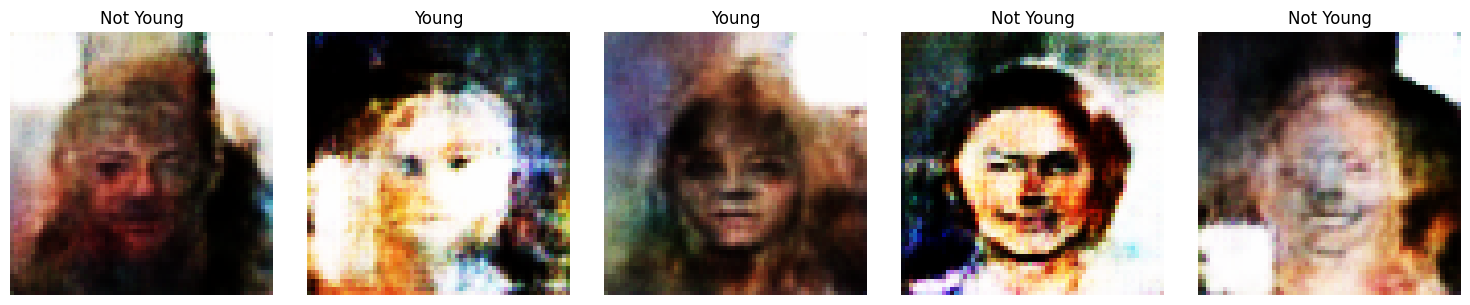

In [ ]:
plot_images(TensorDataset(synthetic_images, synthetic_labels), title="Sample Synthetic Images with Predicted Labels")

In [ ]:
# ### Part 6: Training a Classifier on Real Data + Synthetic Data ###
print("\nPart 6: Train Classifier on Real + Synthetic Data")

# Create mixed dataset
num_real = int(len(train_dataset) * 0.3)
real_indices = np.random.choice(len(train_dataset), num_real, replace=False)
real_subset = Subset(train_dataset_young, real_indices)
synthetic_dataset = TensorDataset(synthetic_images, synthetic_labels)
mixed_dataset = ConcatDataset([real_subset, synthetic_dataset])
mixed_loader = DataLoader(mixed_dataset, batch_size=batch_size, shuffle=True)

In [ ]:
# Train new classifier
classifier_mixed = CNNClassifier1().to(device)
optimizer_mixed = optim.Adam(classifier_mixed.parameters(), lr=1e-3)


In [ ]:
train_classifier(classifier_mixed, mixed_loader, valid_loader, optimizer_mixed, epoch = 10)

Epoch 1: Train Loss 0.4752, Val Loss 0.3913
Epoch 2: Train Loss 0.4021, Val Loss 0.3661
Epoch 3: Train Loss 0.3753, Val Loss 0.3587
Epoch 4: Train Loss 0.3561, Val Loss 0.3469
Epoch 5: Train Loss 0.3469, Val Loss 0.3380
Epoch 6: Train Loss 0.3351, Val Loss 0.3352
Epoch 7: Train Loss 0.3282, Val Loss 0.3299
Epoch 8: Train Loss 0.3226, Val Loss 0.3288
Epoch 9: Train Loss 0.3173, Val Loss 0.3308
Epoch 10: Train Loss 0.3118, Val Loss 0.3272
Training complete.


In [ ]:
# Evaluation function
def evaluate_classifier(model, test_loader):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            preds = (outputs > 0.5).float()
            all_preds.append(preds.cpu())
            all_labels.append(labels.cpu())
    all_preds = torch.cat(all_preds)
    all_labels = torch.cat(all_labels)
    accuracy = (all_preds == all_labels).float().mean().item()
    precision = (all_preds[all_preds == 1] == all_labels[all_preds == 1]).float().mean().item() if all_preds.sum() > 0 else 0
    recall = (all_preds[all_labels == 1] == 1).float().mean().item() if all_labels.sum() > 0 else 0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
    return accuracy, precision, recall, f1

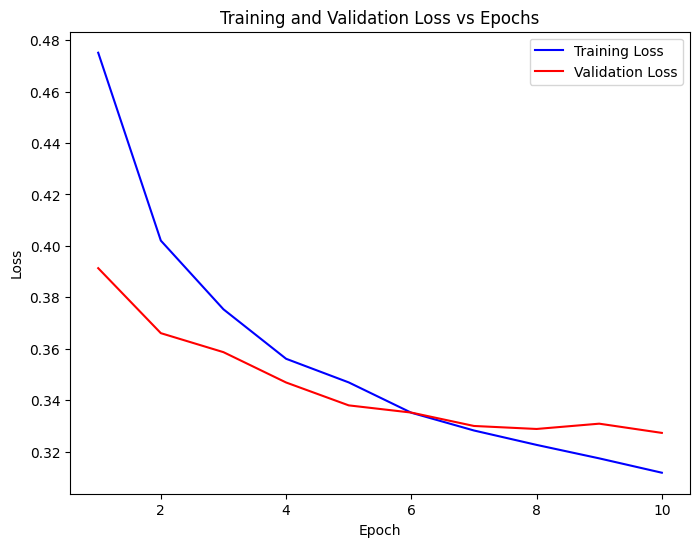

In [ ]:
test_loss, test_acc, all_labels, all_preds = evaluate_model(classifier_mixed, test_loader)
print(f"Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.2f}%")

Test Loss: 0.3317, Test Acc: 86.46%


In [ ]:
# Evaluation metrics
print("Classification Report:")
print(classification_report(all_labels, all_preds, digits=4))

Classification Report:
              precision    recall  f1-score   support

         0.0     0.7450    0.6234    0.6788      4649
         1.0     0.8930    0.9365    0.9142     15612

    accuracy                         0.8646     20261
   macro avg     0.8190    0.7799    0.7965     20261
weighted avg     0.8591    0.8646    0.8602     20261

